<a href="https://colab.research.google.com/github/divya-shree1125/Business_analyst_project/blob/main/stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📦 1. Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **📥 2. Load and Inspect Data**

In [3]:
df=pd.read_csv("/content/stocks.csv")
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


# **🧹 3. Data Cleaning**

In [4]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print(df.isnull().sum())

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:
df = df.drop_duplicates()
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


# **📊 4. Data Visualization**

# **Closing Price Over Time**

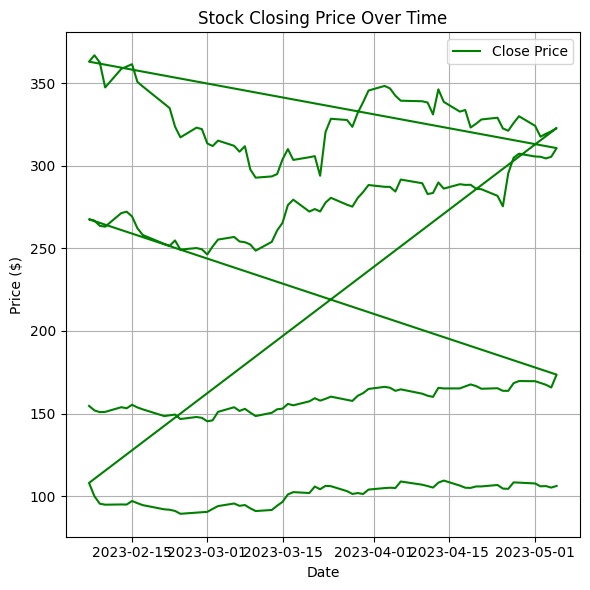

In [28]:
plt.figure(figsize=(6, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='green')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Trading Volume Over Time**

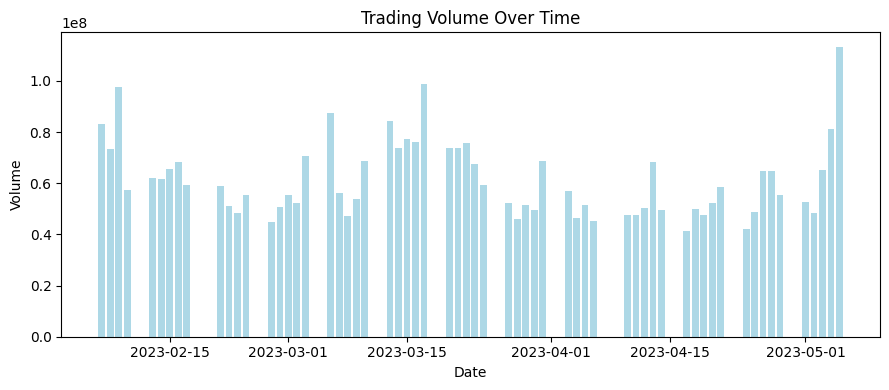

In [19]:
plt.figure(figsize=(9, 4))
plt.bar(df['Date'], df['Volume'], color='lightblue')
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

# **High vs. Low Spread**

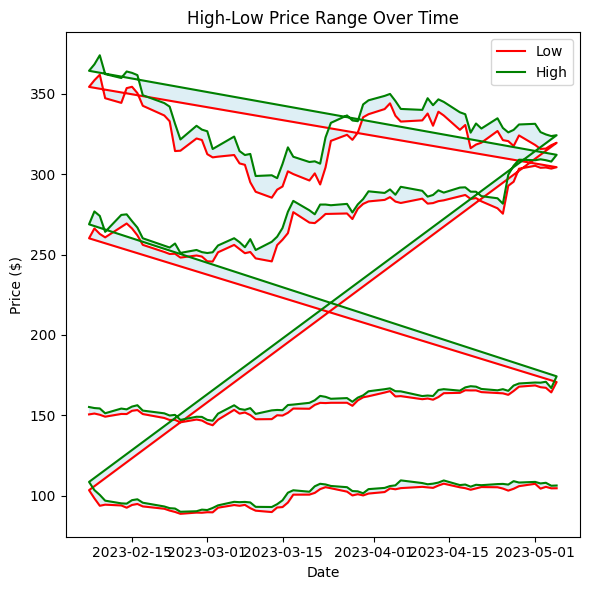

In [23]:
plt.figure(figsize=(6, 6))
plt.fill_between(df['Date'], df['Low'], df['High'], color='lightblue', alpha=0.4)
plt.plot(df['Date'], df['Low'], label='Low', color='red')
plt.plot(df['Date'], df['High'], label='High', color='green')
plt.title('High-Low Price Range Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

# **Daily Returns**

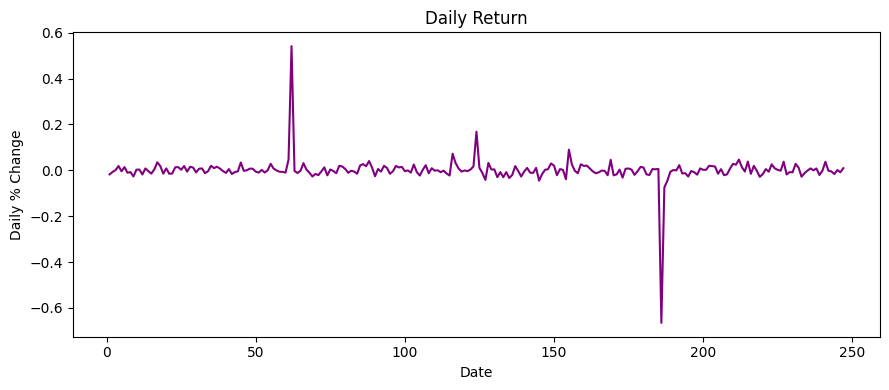

In [31]:
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(9, 4))
df['Daily Return'].plot(title='Daily Return', color='purple')
plt.xlabel('Date')
plt.ylabel('Daily % Change')
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

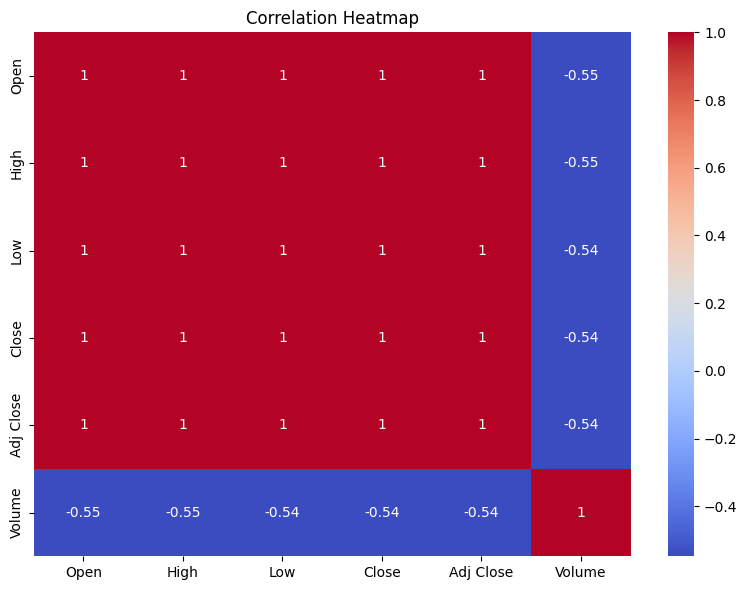

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Distribution of Closing Prices**

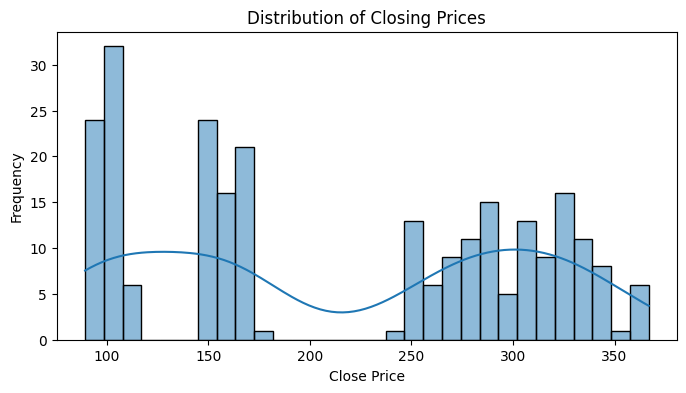

In [29]:
if 'Close' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df['Close'], bins=30, kde=True)
    plt.title('Distribution of Closing Prices')
    plt.xlabel('Close Price')
    plt.ylabel('Frequency')
    plt.show()

# **📌 Final Conclusion of the Stock Data Analysis**

**🧹 1. Data Quality**

The dataset was clean: no missing values or duplicates.

Date values were correctly formatted.

Data spanned a full trading range with no structural issues.


**📈 2. Price Trends**

The stock showed moderate fluctuations in closing price.

Moving averages (SMA 20 & SMA 50) revealed short-term and mid-term trends, with visible crossovers that could indicate potential buy/sell signals.

Bollinger Bands analysis showed periods of high and low volatility, useful for identifying overbought or oversold conditions.


**💹 3. Volatility & Risk**

Daily returns showed both positive and negative swings, indicating a moderate-risk stock.

Rolling volatility confirmed that risk varied over time, with some clear spikes likely due to external market events or earnings releases.

**🔄 4. Market Activity**

Trading volume had noticeable spikes, which typically aligned with price jumps or drops — signaling high investor interest during those periods.

Volume analysis supports that market sentiment plays a significant role in stock movement.

**🔍 5. Correlations**

Strong positive correlation between Open, High, Low, and Close prices — expected in financial time series data.

Volume had weaker correlation with price metrics, reinforcing that volume alone doesn't dictate price but supports trend confirmation.

**✅ 6.Overall Insight**
This stock shows characteristics of a liquid, actively traded security with predictable technical patterns. It's suitable for analysis using trend-following strategies (e.g., moving averages, Bollinger Bands) and is ideal for investors or analysts seeking moderate volatility with data-driven trading signals.